In [74]:
import numpy as np
import pandas as pd

In [75]:
# df = pd.read_csv("spam.csv", encoding='utf-8') # fails if bytes don't fit valid UTF-8 pattern
# df = pd.read_csv("spam.csv", encoding='latin1') # never fails but may show wrong text
df = pd.read_csv("spam.csv", encoding='Windows-1252')  # chardet detected this encoding

In [76]:
# To detect encoding type in any file
%pip install chardet


Note: you may need to restart the kernel to use updated packages.


In [77]:
import chardet
with open('spam.csv', 'rb') as f: #IMP open in binary-mode
    text = f.read(5000)

encoding = chardet.detect(text)
print("encoder result: ", encoding)

encoder result:  {'encoding': 'Windows-1252', 'confidence': 0.7197765921973991, 'language': ''}


In [78]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [79]:
df.shape

(5572, 5)

Steps We will be Performing:
> Data Cleaning  
> Exploratory Data Analysis (EDA)  
> Text Preprocessing  
> Model Building  
> Evaluation  
> Improvement  
> Website  
> Deploy

## 1. Data Cleaning
Includes:  
Dropping Unnecessary Columns,  
Renaming the columns if necessary,  
Encoding the target variable,  
Checking for missing values or duplicate values and act accordingly

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [81]:
df.drop(columns=['Unnamed: 2','Unnamed: 3', 'Unnamed: 4'], inplace=True) #IMP - I almost forgot inplace

In [82]:
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)

In [83]:
df.sample(5)

,target,text
1380,ham,i dnt wnt to tlk wid u
1460,ham,Yalru lyfu astne chikku.. Bt innu mundhe lyf a...
1957,ham,Take something for pain. If it moves however t...
2989,ham,"Love isn't a decision, it's a feeling. If we c..."
541,ham,A famous quote : when you develop the ability ...


In [84]:
from sklearn.preprocessing import LabelEncoder

In [85]:
encoder = LabelEncoder()

df['target'] = encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [86]:
df.isna().sum()

target    0
text      0
dtype: int64

In [87]:
df.duplicated().sum()

np.int64(403)

In [88]:
df.drop_duplicates(keep='first', inplace=True)

In [89]:
df.duplicated().sum()

np.int64(0)

## 2. Exploratory Data Analysis (EDA)

In [90]:
# 1. Check data imbalances
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x75edb3f68b30>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

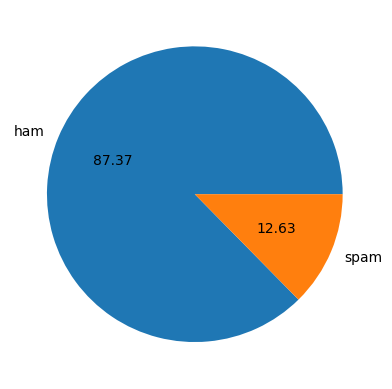

In [91]:
import matplotlib.pyplot as plt

plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')

In [92]:
# Data is imbalanced, We need to keep this in mind

# we will count no. of characters, words and sentences
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/sakshi-
[nltk_data]     khatiwada/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/sakshi-
[nltk_data]     khatiwada/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [93]:
df['number_of_characters'] = df['text'].apply(len)

In [94]:
df.head()

,target,text,number_of_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [95]:
df['number_of_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [96]:
df['number_of_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [97]:
df.head()

,target,text,number_of_characters,number_of_words,number_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [98]:
df[['number_of_characters', 'number_of_words', 'number_of_sentences']].describe()

,number_of_characters,number_of_words,number_of_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [99]:
df[df['target'] == 0][['number_of_characters', 'number_of_words', 'number_of_sentences']].describe() # ham's description

,number_of_characters,number_of_words,number_of_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [100]:
df[df['target'] == 1][['number_of_characters', 'number_of_words', 'number_of_sentences']].describe() # spam's description

,number_of_characters,number_of_words,number_of_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [101]:
import seaborn as sns

<Axes: xlabel='number_of_characters', ylabel='Count'>

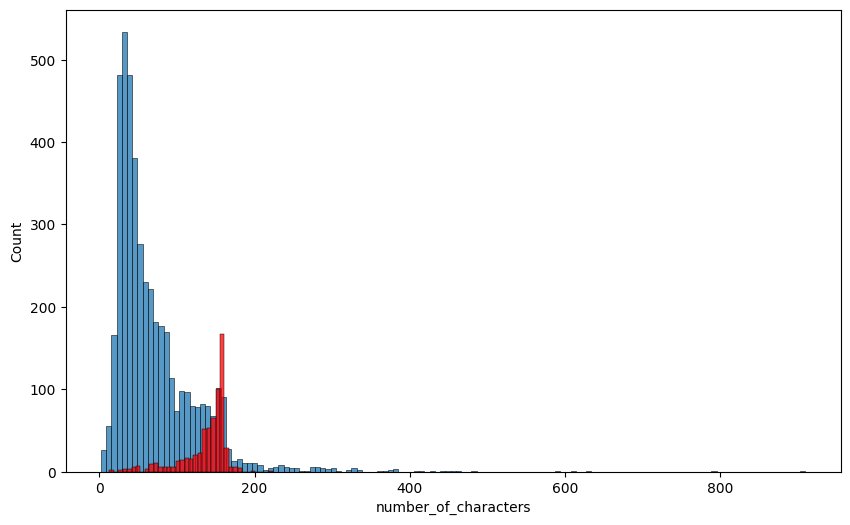

In [102]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['number_of_characters'])
sns.histplot(df[df['target'] == 1]['number_of_characters'], color='red')

<Axes: xlabel='number_of_words', ylabel='Count'>

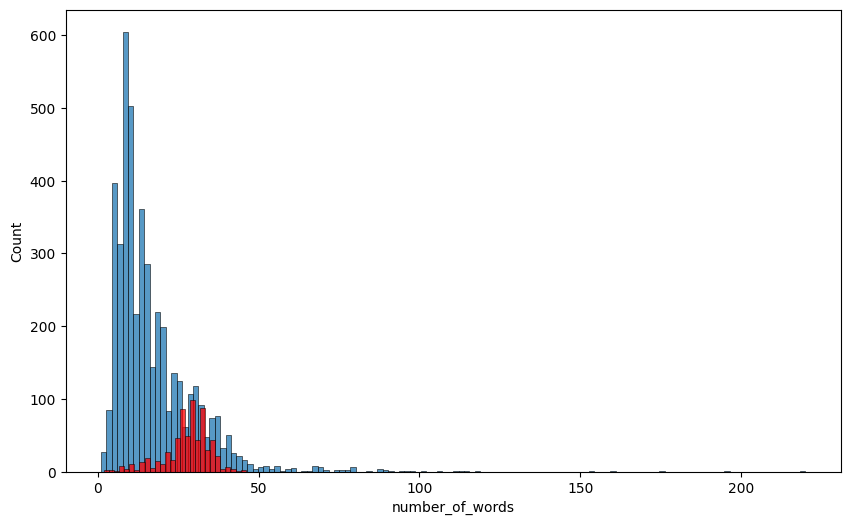

In [103]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['number_of_words'])
sns.histplot(df[df['target'] == 1]['number_of_words'], color='red')

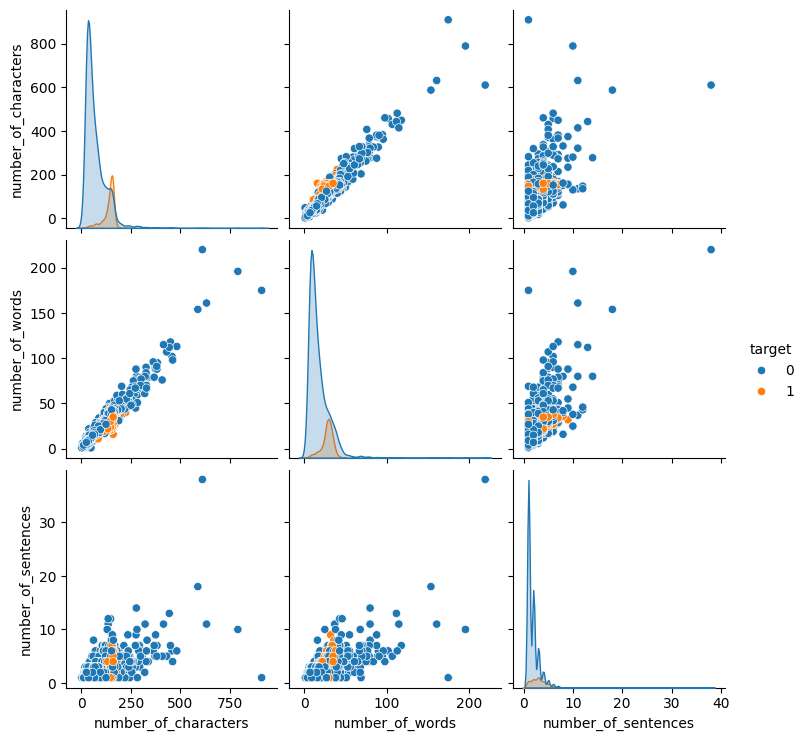

In [104]:
sns.pairplot(df, hue='target')

<Axes: >

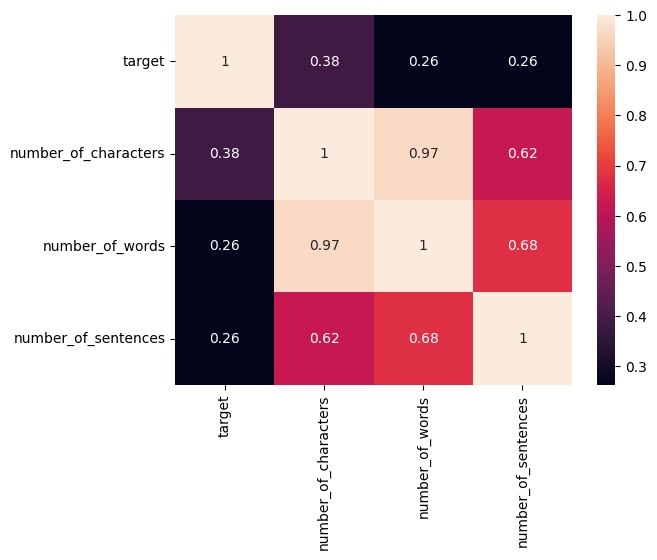

In [105]:
# sns.heatmap(df.corr()) # not supposed to throw error but did. Didn't implicitly ignored non-numeric column

# df.select_dtypes(include='number').corr()
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

## 3. Data Preprocessing

In [106]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer # Porter is the person who wrote this Stemming algorithm

In [107]:
ps = PorterStemmer()

In [108]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/sakshi-
[nltk_data]     khatiwada/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [109]:
import string

string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [110]:
# Starting with Transforming text
# lower case, tokenization, removing special characters, removing stop words and punctuations, stemming

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for word in text:
        if word.isalnum():
            y.append(word)
            
    text = y[:] # pitfall, this is list cloning. We can't directly assign a list to make a copy
    y.clear()
    
    for word in text:
        if word not in stopwords.words('english') and word not in string.punctuation:
            y.append(word)
            
            
    text = y[:]
    y.clear()
    
    for word in text:
        y.append(ps.stem(word))
        
    return " ".join(y)

In [111]:
transform_text("hi? i am having gathering saKSHI.")

'hi gather sakshi'

In [112]:
def transform_text_modified(text):
    """
    Preprocess the text and returns string
    """
    
    tokens_list = nltk.word_tokenize(text.lower())
    
    processed = []
    
    for word in tokens_list:
        if word.isalnum() and word not in stopwords.words('english') and word not in string.punctuation:
            processed.append(ps.stem(word))
    
    return " ".join(processed)

In [113]:
transform_text_modified("hi? i am having gathering saKSHI.")

'hi gather sakshi'

In [114]:
df['transformed_text'] = df['text'].apply(transform_text_modified)

### Word Cloud

In [115]:
from wordcloud import WordCloud

wc = WordCloud(height=500, width=500, min_font_size=8, background_color='white')

In [116]:
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=' '))
# ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=' ')) # Pitfall. If I use it like this, the wc is the same object, so it will override the previous wordcloud.

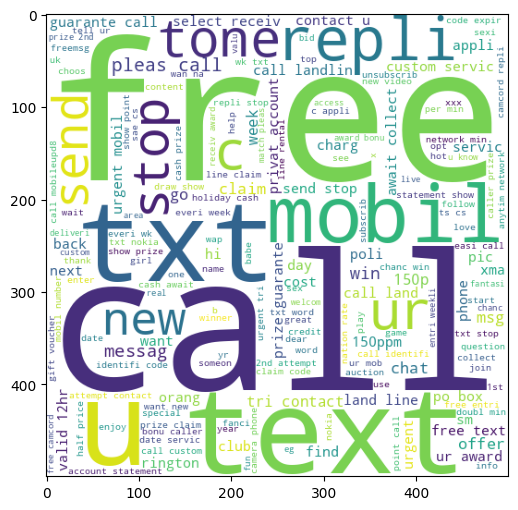

In [117]:
plt.figure(figsize=(10,6))
plt.imshow(spam_wc)

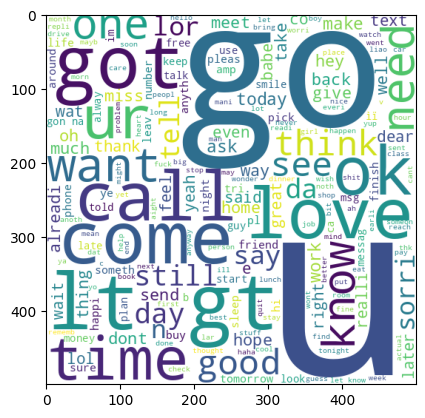

In [118]:
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=' '))
plt.imshow(ham_wc)

In [119]:
df.head()

,target,text,number_of_characters,number_of_words,number_of_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [129]:
# Eventhough WordCloud clearly shows the top words, we are gonna find what are the top words anyway!
spam_words = []

for sentences in df[df['target'] == 1]['transformed_text'].tolist():
    for word in sentences.split(): # first split into a list, then retrieve every word
        spam_words.append(word)
        
spam_words

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

In [130]:
from collections import Counter

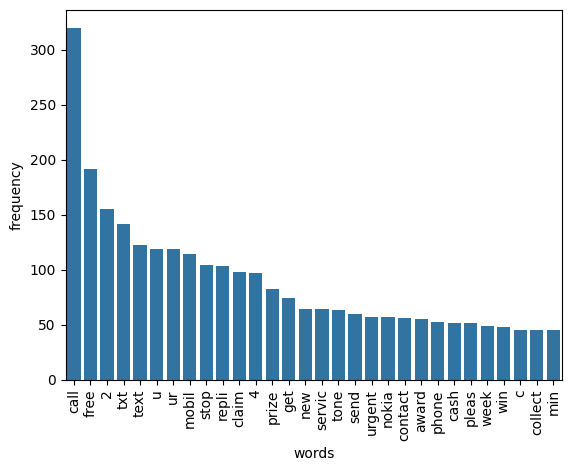

In [142]:
sns.barplot(x = pd.DataFrame(Counter(spam_words).most_common(30))[0],y= pd.DataFrame(Counter(spam_words).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.xlabel("words")
plt.ylabel("frequency")
plt.show()


In [143]:
ham_words = []

for sentences in df[df['target'] == 0]['transformed_text'].tolist():
    for word in sentences.split(): # first split into a list, then retrieve every word
        ham_words.append(word)
        
len(ham_words)

35404

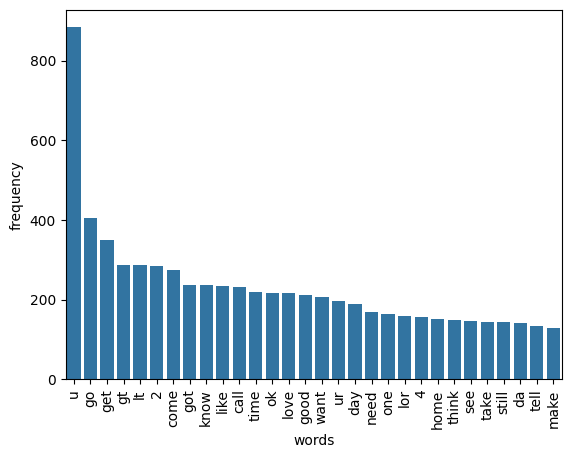

In [144]:
sns.barplot(x = pd.DataFrame(Counter(ham_words).most_common(30))[0],y= pd.DataFrame(Counter(ham_words).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.xlabel("words")
plt.ylabel("frequency")
plt.show()